# 과제 4-1. LEAD 1.0 데이터 파악 및 BDG2 조인

In [1]:
import sys
sys.path.append("..")
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from src.backtest import rolling_backtest
from src.features import build_features
from src.metrics import mae, compute_naive_denominators, score_backtest

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
os.makedirs("../results/wk4", exist_ok=True)

data_full = pd.read_csv(
    "../Data/processed/subset_17_buildings_Impulation.csv",
    encoding="utf-8", index_col=0, parse_dates=True,
)
subset = pd.read_csv("../Data/raw/subset_17_buildings.csv", encoding="utf-8")
meta = pd.read_csv("../Data/raw/bdg2/metadata.csv", encoding="utf-8")
meta["building_id_kaggle"] = meta["building_id_kaggle"].astype("Int64")

lead = pd.read_csv("../Data/raw/lead/lead1.0-small.csv", encoding="utf-8")
lead["timestamp"] = pd.to_datetime(lead["timestamp"])

print("LEAD 1.0 shape:", lead.shape)
print("LEAD 건물 수:", lead["building_id"].nunique())
print("LEAD 기간:", lead["timestamp"].min(), "~", lead["timestamp"].max())
print("LEAD 전체 이상률: {:.4f}%".format((lead["anomaly"] == 1).mean() * 100))
print("LEAD 컬럼:", lead.columns.tolist(), "(meter_reading이 하나뿐 -> electricity 전용 라벨로 확인됨)")


C:\Users\dong\miniconda3\envs\Self_directed_Project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LEAD 1.0 shape: (1749494, 4)
LEAD 건물 수: 200
LEAD 기간: 2016-01-01 00:00:00 ~ 2016-12-31 23:00:00
LEAD 전체 이상률: 2.1318%
LEAD 컬럼: ['building_id', 'timestamp', 'meter_reading', 'anomaly'] (meter_reading이 하나뿐 -> electricity 전용 라벨로 확인됨)


In [ ]:
kaggle_map = meta.set_index("building_id_kaggle")["building_id"].dropna() 
lead_ids = pd.Series(lead["building_id"].unique()).astype("Int64")

joined_all = kaggle_map.index.astype("Int64").isin(lead_ids)
print("BDG2 전체 조인 매칭 건물 수:", joined_all.sum(), "/", len(lead_ids), "(LEAD 200개 전부와 매칭되어야 정상)")

our17 = subset["building_id"].tolist()
our_kaggle = meta.loc[meta["building_id"].isin(our17), ["building_id", "building_id_kaggle"]].dropna()
matched17 = our_kaggle["building_id_kaggle"].astype("Int64").isin(lead_ids).sum()
print(f"우리 17개 서브셋 중 매칭된 건물 수: {matched17} / {len(our17)}")
assert matched17 == 17

kaggle_to_name = our_kaggle.set_index("building_id_kaggle")["building_id"].to_dict()
print("\nkaggle_id -> BDG2 이름 매핑(우리 17개):")
print(kaggle_to_name)


BDG2 전체 조인 매칭 건물 수: 200 / 200 (LEAD 200개 전부와 매칭되어야 정상)
우리 17개 서브셋 중 매칭된 건물 수: 17 / 17

kaggle_id -> BDG2 이름 매핑(우리 17개):
{np.int64(159): 'Fox_education_Charles', np.int64(181): 'Fox_education_Elvira', np.int64(275): 'Fox_office_Vicki', np.int64(276): 'Fox_office_Joy', np.int64(293): 'Rat_office_Adele', np.int64(318): 'Rat_office_Craig', np.int64(335): 'Rat_office_Lora', np.int64(356): 'Rat_public_Julieann', np.int64(423): 'Rat_assembly_Pauline', np.int64(439): 'Rat_office_Randy', np.int64(534): 'Rat_assembly_Kelley', np.int64(623): 'Bear_education_Lewis', np.int64(653): 'Bear_education_Chad', np.int64(977): 'Bull_office_Ella', np.int64(990): 'Bull_office_Sally', np.int64(1120): 'Hog_services_Marshall', np.int64(1141): 'Hog_parking_Antoinette'}


In [ ]:
lead17 = lead[lead["building_id"].isin(kaggle_to_name.keys())].copy()
lead17["building"] = lead17["building_id"].map(kaggle_to_name)

anomaly_wide = lead17.pivot(index="timestamp", columns="building", values="anomaly").reindex(columns=our17)
lead_meter_wide = lead17.pivot(index="timestamp", columns="building", values="meter_reading").reindex(columns=our17)

print("anomaly_wide shape:", anomaly_wide.shape)
print("건물별 이상률 (2016년, %):")
print((anomaly_wide == 1).mean().mul(100).round(3).sort_values(ascending=False))

# 이상 구간 길이 분포
def run_lengths(mask):
    lens, cur = [], 0
    for v in mask:
        if v:
            cur += 1
        else:
            if cur > 0:
                lens.append(cur)
            cur = 0
    if cur > 0:
        lens.append(cur)
    return lens

all_runs = []
for bid in our17:
    all_runs.extend(run_lengths((anomaly_wide[bid] == 1).values))
all_runs = pd.Series(all_runs)
print(f"\n우리 17개 기준 이상 구간 개수: {len(all_runs)}")
print(all_runs.describe())


anomaly_wide shape: (8784, 17)
건물별 이상률 (2016년, %):


building
Rat_office_Randy          6.455
Fox_education_Charles     3.438
Rat_office_Lora           2.937
Bear_education_Chad       2.846
Rat_assembly_Kelley       2.801
Bull_office_Sally         2.368
Hog_parking_Antoinette    1.947
Fox_office_Vicki          1.890
Bull_office_Ella          1.856
Bear_education_Lewis      1.639
Fox_office_Joy            1.400
Rat_office_Craig          1.366
Fox_education_Elvira      1.195
Hog_services_Marshall     1.150
Rat_public_Julieann       1.150
Rat_office_Adele          1.047
Rat_assembly_Pauline      0.990
dtype: float64

우리 17개 기준 이상 구간 개수: 397
count    397.000000
mean       8.070529
std        8.983996
min        1.000000
25%        3.000000
50%        7.000000
75%       10.000000
max       72.000000
dtype: float64


# 과제 4-2. 정상 구간만으로 학습 (vs 전체 구간 오염 학습)

In [ ]:
#정상 구간만 학습
LGB_PARAMS = dict(objective="regression", num_leaves=127, learning_rate=0.08,
                   n_estimators=300, min_child_samples=10, verbosity=-1)

def make_global_fns(feat_horizon, anomaly_mask=None, lgb_params=LGB_PARAMS):
    def model_fn(train_df):
        if anomaly_mask is not None:
            m = anomaly_mask.reindex(train_df.index)
            train_for_fit = train_df.mask(m == 1)   # 이상 시점만 NaN -> build_features의 dropna로 학습에서 제외
        else:
            train_for_fit = train_df
        feat = build_features(train_for_fit, feat_horizon).dropna(subset=["y"])
        X = feat.drop(columns=["timestamp", "y"]).copy()
        X["building"] = X["building"].astype("category")
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X, feat["y"], categorical_feature=["building"])
        return {"model": model, "train_df": train_df, "columns": X.columns.tolist()}

    def predict_fn(state, horizon):
        train_df = state["train_df"]
        future_index = pd.date_range(train_df.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
        extended = pd.concat([train_df, pd.DataFrame(np.nan, index=future_index, columns=train_df.columns)])
        feat = build_features(extended, feat_horizon)
        feat = feat[feat["timestamp"].isin(future_index)].copy()
        X = feat[state["columns"]].copy()
        X["building"] = X["building"].astype("category")
        feat["pred"] = state["model"].predict(X)
        return feat.pivot(index="timestamp", columns="building", values="pred").reindex(columns=train_df.columns)

    return model_fn, predict_fn

# 기간을 2016년으로 한정(LEAD 라벨이 2016년뿐) + n_windows=4로 축소
data_2016 = data_full.loc["2016-01-01":"2016-12-31", our17]
anomaly_2016 = anomaly_wide.reindex(data_2016.index)

N_WINDOWS_4W = 4
STEP_SIZE = 168
FINAL_TRAIN_MODE = "expanding"
HORIZON = 24

print("2016년 데이터 shape:", data_2016.shape)
print("2016년 총 이상 시점 수:", int((anomaly_2016 == 1).sum().sum()))


2016년 데이터 shape: (8784, 17)
2016년 총 이상 시점 수: 3204


In [ ]:
model_fn_clean, predict_fn_clean = make_global_fns(HORIZON, anomaly_mask=anomaly_2016)
res_clean = rolling_backtest(data_2016, model_fn_clean, predict_fn_clean, n_windows=N_WINDOWS_4W,
                              horizon=HORIZON, train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

model_fn_cont, predict_fn_cont = make_global_fns(HORIZON, anomaly_mask=None)
res_cont = rolling_backtest(data_2016, model_fn_cont, predict_fn_cont, n_windows=N_WINDOWS_4W,
                             horizon=HORIZON, train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

anomaly_long = anomaly_2016.stack().rename("is_anomaly").rename_axis(["timestamp", "building"]).reset_index()

res_clean = res_clean.merge(anomaly_long, on=["timestamp", "building"], how="left")
res_cont = res_cont.merge(anomaly_long, on=["timestamp", "building"], how="left")
res_clean["resid"] = (res_clean["y_true"] - res_clean["y_pred"]).abs()
res_cont["resid"] = (res_cont["y_true"] - res_cont["y_pred"]).abs()

res_clean.to_csv("../results/wk4/residuals_clean_model.csv", index=False, encoding="utf-8")
res_cont.to_csv("../results/wk4/residuals_contaminated_model.csv", index=False, encoding="utf-8")

print("정상학습 모델 평가 행 수:", len(res_clean), "| 이상 라벨=1인 행 수:", int((res_clean["is_anomaly"]==1).sum()))
print("오염학습 모델 평가 행 수:", len(res_cont), "| 이상 라벨=1인 행 수:", int((res_cont["is_anomaly"]==1).sum()))


정상학습 모델 평가 행 수: 1632 | 이상 라벨=1인 행 수: 30
오염학습 모델 평가 행 수: 1632 | 이상 라벨=1인 행 수: 30


# 과제 4-3. 잔차 기반 탐지 — 정상학습 vs 오염학습 비교

  모델  정상구간 평균잔차  이상구간 평균잔차  이상/정상 비율
정상학습  16.656432    5.26683  0.316204
오염학습  18.388716    5.68095  0.308937

오염 학습으로 인한 이상구간 탐지력(평균잔차) 저하: -7.9%


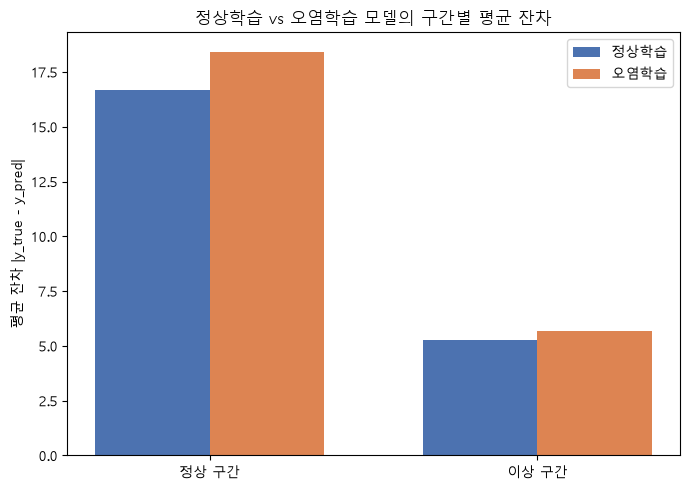

In [6]:
def resid_summary(res, label):
    normal = res.loc[res["is_anomaly"] == 0, "resid"].mean()
    anomaly = res.loc[res["is_anomaly"] == 1, "resid"].mean()
    return {"모델": label, "정상구간 평균잔차": normal, "이상구간 평균잔차": anomaly, "이상/정상 비율": anomaly / normal}

summary = pd.DataFrame([resid_summary(res_clean, "정상학습"), resid_summary(res_cont, "오염학습")])
degrade_pct = (summary.loc[0, "이상구간 평균잔차"] - summary.loc[1, "이상구간 평균잔차"]) / summary.loc[0, "이상구간 평균잔차"] * 100
summary.to_csv("../results/wk4/residual_summary.csv", index=False, encoding="utf-8")
print(summary.to_string(index=False))
print(f"\n오염 학습으로 인한 이상구간 탐지력(평균잔차) 저하: {degrade_pct:.1f}%")

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [summary.loc[0, "정상구간 평균잔차"], summary.loc[0, "이상구간 평균잔차"]], w, label="정상학습", color="#4C72B0")
ax.bar(x + w/2, [summary.loc[1, "정상구간 평균잔차"], summary.loc[1, "이상구간 평균잔차"]], w, label="오염학습", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(["정상 구간", "이상 구간"])
ax.set_ylabel("평균 잔차 |y_true - y_pred|")
ax.set_title("정상학습 vs 오염학습 모델의 구간별 평균 잔차")
ax.legend()
plt.tight_layout()
plt.savefig("../results/wk4/residual_clean_vs_contaminated.png", dpi=110)
plt.show()


## 연간 전체 커버리지로 재분석

- 모델을 한 번씩만 학습(전체 2016년 사용, 정상학습은 이상 시점 마스킹)하고, 2016년 전체에 대해 예측해서 잔차를 낸다.
- 연속, 마스킹만 제거하고 이상 시점만 남김

In [ ]:
state_clean_full = model_fn_clean(data_2016)
state_cont_full = model_fn_cont(data_2016)

feat_all = build_features(data_2016, HORIZON)
X_all = feat_all.drop(columns=["timestamp", "y"]).copy()
X_all["building"] = X_all["building"].astype("category")

feat_all["pred_clean"] = state_clean_full["model"].predict(X_all[state_clean_full["columns"]])
feat_all["pred_cont"] = state_cont_full["model"].predict(X_all[state_cont_full["columns"]])
feat_all = feat_all.merge(anomaly_long, on=["timestamp", "building"], how="left")

scored = feat_all.dropna(subset=["y"]).copy() 
scored["resid_clean"] = (scored["y"] - scored["pred_clean"]).abs()
scored["resid_cont"] = (scored["y"] - scored["pred_cont"]).abs()

norm_base = scored.loc[scored["is_anomaly"] == 0].groupby("building")["resid_clean"].mean()
scored["resid_clean_norm"] = scored["resid_clean"] / scored["building"].map(norm_base)
scored["resid_cont_norm"] = scored["resid_cont"] / scored["building"].map(norm_base)

scored.to_csv("../results/wk4/residuals_full_year.csv", index=False, encoding="utf-8")
print("연간 전체 평가 행 수:", len(scored), "| 이상 라벨=1:", int((scored["is_anomaly"]==1).sum()))
print("건물별 이상 시점 커버리지:")
print(scored.groupby("building")["is_anomaly"].sum().sort_values(ascending=False))


연간 전체 평가 행 수: 149120 | 이상 라벨=1: 3109
건물별 이상 시점 커버리지:
building
Rat_office_Randy          567.0
Fox_education_Charles     302.0
Rat_office_Lora           258.0
Bear_education_Chad       250.0
Rat_assembly_Kelley       238.0
Bull_office_Sally         208.0
Hog_parking_Antoinette    171.0
Fox_office_Vicki          166.0
Bull_office_Ella          163.0
Bear_education_Lewis      144.0
Fox_office_Joy            123.0
Rat_office_Craig          120.0
Fox_education_Elvira      105.0
Rat_public_Julieann       101.0
Rat_office_Adele           92.0
Rat_assembly_Pauline       87.0
Hog_services_Marshall      14.0
Name: is_anomaly, dtype: float64


  모델  정상구간 정규화잔차  이상구간 정규화잔차
정상학습    1.000000    7.234534
오염학습    0.846961    2.042940

오염 학습으로 인한 이상구간 탐지력(정규화잔차) 저하: 71.8%


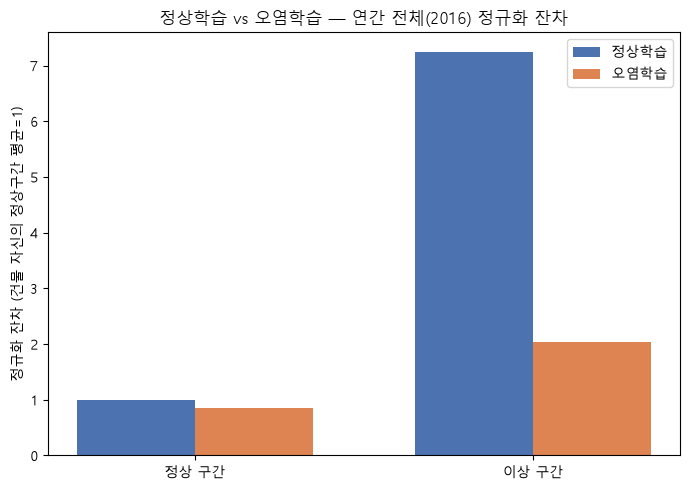

In [8]:
def resid_summary_norm(col, label):
    normal = scored.loc[scored["is_anomaly"] == 0, col].mean()
    anomaly = scored.loc[scored["is_anomaly"] == 1, col].mean()
    return {"모델": label, "정상구간 정규화잔차": normal, "이상구간 정규화잔차": anomaly}

summary_full = pd.DataFrame([
    resid_summary_norm("resid_clean_norm", "정상학습"),
    resid_summary_norm("resid_cont_norm", "오염학습"),
])
degrade_pct_full = ((summary_full.loc[0, "이상구간 정규화잔차"] - summary_full.loc[1, "이상구간 정규화잔차"])
                     / summary_full.loc[0, "이상구간 정규화잔차"] * 100)
summary_full.to_csv("../results/wk4/residual_summary_full_year.csv", index=False, encoding="utf-8")
print(summary_full.to_string(index=False))
print(f"\n오염 학습으로 인한 이상구간 탐지력(정규화잔차) 저하: {degrade_pct_full:.1f}%")

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [summary_full.loc[0, "정상구간 정규화잔차"], summary_full.loc[0, "이상구간 정규화잔차"]], w, label="정상학습", color="#4C72B0")
ax.bar(x + w/2, [summary_full.loc[1, "정상구간 정규화잔차"], summary_full.loc[1, "이상구간 정규화잔차"]], w, label="오염학습", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(["정상 구간", "이상 구간"])
ax.set_ylabel("정규화 잔차 (건물 자신의 정상구간 평균=1)")
ax.set_title("정상학습 vs 오염학습 — 연간 전체(2016) 정규화 잔차")
ax.legend()
plt.tight_layout()
plt.savefig("../results/wk4/residual_clean_vs_contaminated_full_year.png", dpi=110)
plt.show()


# 과제 4-4. 임계값 4안 비교 (정상학습 모델의 잔차 기준)

In [ ]:
det = scored.sort_values(["building", "timestamp"]).copy()

# 1) 고정 절대값
fixed_abs_threshold = det["resid_clean"].median() * 3
det["flag_fixed_abs"] = det["resid_clean"] > fixed_abs_threshold

# 2) 고정 백분위
det["flag_fixed_pct"] = det.groupby("building")["resid_clean"].transform(lambda s: s > s.quantile(0.99))

# 3) 표준편차 배수
def std_threshold(g):
    return g["resid_clean"].mean() + 3 * g["resid_clean"].std()
std_thr = det.groupby("building").apply(std_threshold, include_groups=False)
det["flag_std3"] = det["resid_clean"] > det["building"].map(std_thr)

# 4) 동적(롤링)
def rolling_threshold(g):
    g = g.sort_values("timestamp")
    roll = g["resid_clean"].shift(1).rolling(336, min_periods=48)
    return roll.mean() + 3 * roll.std()
det["dyn_threshold"] = det.groupby("building", group_keys=False).apply(rolling_threshold, include_groups=False)
det["flag_dynamic"] = det["resid_clean"] > det["dyn_threshold"]
det.loc[det["dyn_threshold"].isna(), "flag_dynamic"] = False

def prf(flag_col):
    y_true = det["is_anomaly"] == 1
    y_pred = det[flag_col].fillna(False)
    tp = (y_true & y_pred).sum()
    fp = (~y_true & y_pred).sum()
    fn = (y_true & ~y_pred).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"Precision": precision, "Recall": recall, "F1": f1, "탐지 개수": int(y_pred.sum())}

threshold_compare = pd.DataFrame({
    "고정 절대값": prf("flag_fixed_abs"),
    "고정 백분위(1%)": prf("flag_fixed_pct"),
    "표준편차(μ+3σ)": prf("flag_std3"),
    "동적(롤링 14일)": prf("flag_dynamic"),
}).T
threshold_compare.to_csv("../results/wk4/threshold_comparison.csv", encoding="utf-8")
print(f"고정 절대값 임계값: {fixed_abs_threshold:.2f}")
print(threshold_compare.to_string())


고정 절대값 임계값: 10.27
            Precision    Recall        F1    탐지 개수
고정 절대값       0.048913  0.557092  0.089930  35410.0
고정 백분위(1%)   0.366555  0.176262  0.238054   1495.0
표준편차(μ+3σ)   0.282653  0.267289  0.274756   2940.0
동적(롤링 14일)   0.213165  0.222901  0.217925   3251.0


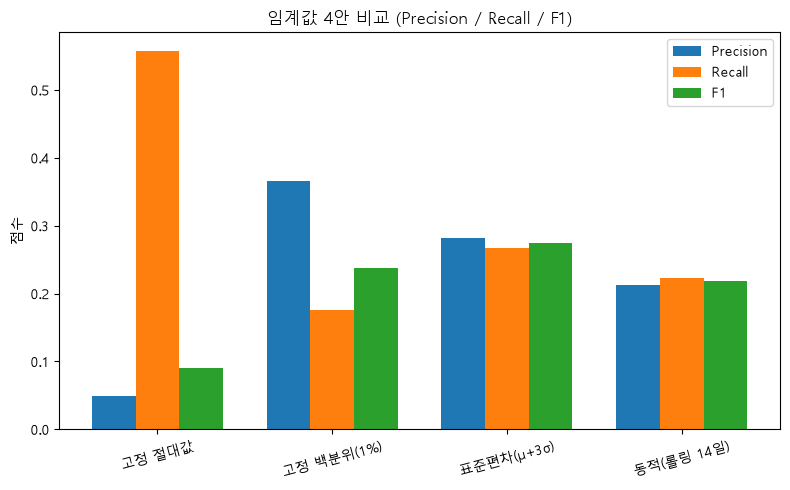

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(threshold_compare))
w = 0.25
for i, metric in enumerate(["Precision", "Recall", "F1"]):
    ax.bar(x + (i - 1) * w, threshold_compare[metric], w, label=metric)
ax.set_xticks(x); ax.set_xticklabels(threshold_compare.index, rotation=15)
ax.set_ylabel("점수")
ax.set_title("임계값 4안 비교 (Precision / Recall / F1)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/wk4/threshold_comparison.png", dpi=110)
plt.show()


# 과제 4-5. SHAP 근거 리포트 (이상 이벤트 3건)

In [11]:
flag_col_map = {"고정 절대값": "flag_fixed_abs", "고정 백분위(1%)": "flag_fixed_pct",
                "표준편차(μ+3σ)": "flag_std3", "동적(롤링 14일)": "flag_dynamic"}
best_method = threshold_compare["F1"].idxmax()
best_flag = flag_col_map[best_method]
print(f"F1 기준 최고 임계값 방식: {best_method} (F1={threshold_compare.loc[best_method, 'F1']:.3f})")

true_positives = det[(det[best_flag]) & (det["is_anomaly"] == 1)].sort_values("resid_clean", ascending=False)
events = true_positives.drop_duplicates(subset="building").head(3)  # 다양성을 위해 서로 다른 건물에서 3건
print(events[["building", "timestamp", "y", "pred_clean", "resid_clean"]].to_string(index=False))

explainer = shap.TreeExplainer(state_clean_full["model"])
feature_cols = state_clean_full["columns"]
X_events = events[feature_cols].copy()
X_events["building"] = pd.Categorical(X_events["building"], categories=sorted(our17))  # 학습 시 카테고리 순서와 반드시 일치시켜야 함
shap_values = explainer.shap_values(X_events)
base_value = explainer.expected_value


F1 기준 최고 임계값 방식: 표준편차(μ+3σ) (F1=0.275)
         building           timestamp       y  pred_clean  resid_clean
Bull_office_Sally 2016-10-15 22:00:00 2383.00   93.132747  2289.867253
 Bull_office_Ella 2016-10-15 22:00:00 1842.00   60.154397  1781.845603
  Rat_office_Lora 2016-10-10 14:00:00  237.69  846.873764   609.183764


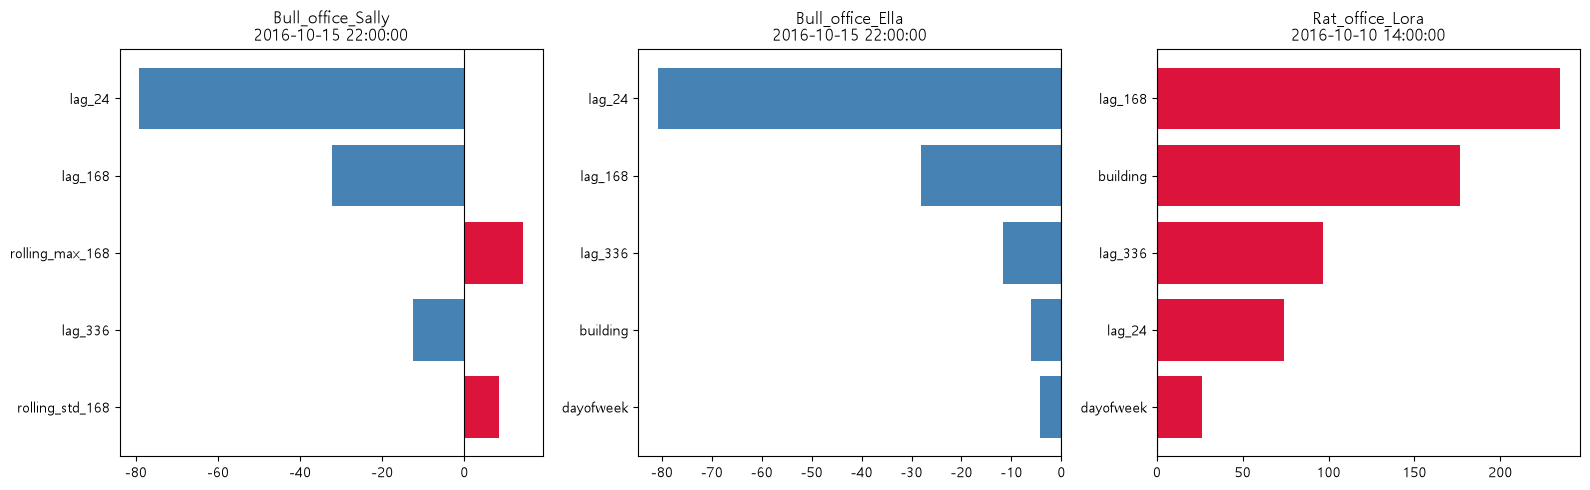

         building           timestamp     실제값        예측값          잔차 top1_피처   top1_기여도  top2_피처   top2_기여도
Bull_office_Sally 2016-10-15 22:00:00 2383.00  93.132747 2289.867253  lag_24 -79.296608  lag_168 -32.269294
 Bull_office_Ella 2016-10-15 22:00:00 1842.00  60.154397 1781.845603  lag_24 -80.702068  lag_168 -28.043618
  Rat_office_Lora 2016-10-10 14:00:00  237.69 846.873764  609.183764 lag_168 234.691275 building 176.770559


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
explain_rows = []
for i, (idx, row) in enumerate(events.iterrows()):
    sv = pd.Series(shap_values[i], index=feature_cols).sort_values(key=abs, ascending=False)
    top5 = sv.head(5)

    ax = axes[i]
    colors = ["crimson" if v > 0 else "steelblue" for v in top5.values[::-1]]
    ax.barh(top5.index[::-1], top5.values[::-1], color=colors)
    ax.set_title(f"{row['building']}\n{row['timestamp']}")
    ax.axvline(0, color="black", linewidth=0.8)

    pred = base_value + sv.sum() 
    explain_rows.append({
        "building": row["building"], "timestamp": row["timestamp"],
        "실제값": row["y"], "예측값": row["pred_clean"], "잔차": row["resid_clean"],
        "top1_피처": top5.index[0], "top1_기여도": top5.iloc[0],
        "top2_피처": top5.index[1], "top2_기여도": top5.iloc[1],
    })
plt.tight_layout()
plt.savefig("../results/wk4/shap_top3_events.png", dpi=110)
plt.show()

explain_df = pd.DataFrame(explain_rows)
explain_df.to_csv("../results/wk4/shap_explanations.csv", index=False, encoding="utf-8")
print(explain_df.to_string(index=False))
